## Import Library

In [1]:
import os
import json
import platform
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
print(f"python : {platform.python_version()}")
print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"tensorflow: {tf.__version__}")
print(f"seeds: {SEEDS}")

NB2_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02"
NB4A_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook04b"

features = pd.read_csv(f"{NB2_DIR}/features_gold.csv")
split = pd.read_csv(f"{NB2_DIR}/split_assignment.csv")

with open(f"{NB4A_DIR}/nb4a_selected_hparams.json") as f:
    selected_params = json.load(f)

MODEL_NAMES = ["Decision Tree", "LightGBM", "XGBoost", "TCN", "GRU", "CNN-LSTM"]

original_split = split[split.group == "original"].copy()
train_rows_pool = original_split[original_split.split == "train"]

mix_rows = split[split.group == "mix"].copy()
mix_paths = mix_rows["path"]
mix_pairing = dict(zip(mix_rows["path"], mix_rows["class"]))

print(f"train pool : {len(train_rows_pool)} eksekusi")
print(f"mix        : {len(mix_paths)} eksekusi, {mix_rows['class'].nunique()} pasangan unik")
print(mix_rows["class"].value_counts().to_string())

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES
FEATURE_COLUMNS_FULL = ALL_FEATURE_NAMES + ["w"]
LOG1P_FEATURES = (
    ["T_s_r", "T_s_w", "V_s_r", "V_s_w"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
LOG1P_IDX = [FEATURE_COLUMNS_FULL.index(f) for f in LOG1P_FEATURES]

def checkpoints_for_step(step, max_w=30):
    return list(range(step, max_w + 1, step))

def build_sequences(df, paths, checkpoint_grid, feature_names):
    sub = df[df["path"].isin(paths) & df["window_s"].isin(checkpoint_grid)]
    sequences, labels = [], []
    for path, g in sub.groupby("path", sort=False):
        g = g.sort_values("window_s")
        assert len(g) == len(checkpoint_grid)
        w = g["window_s"].to_numpy(dtype="float64")
        feat = g[feature_names].to_numpy(dtype="float64")
        sequences.append(np.concatenate([feat, w[:, None]], axis=1))
        labels.append(int(g["is_ransomware"].iloc[0]))
    X = np.stack(sequences).astype("float32")
    y = np.array(labels, dtype="int32")
    return X, y


def build_sequences_tracked(df, paths, checkpoint_grid, feature_names):
    sub = df[df["path"].isin(paths) & df["window_s"].isin(checkpoint_grid)]
    sequences, labels, path_list = [], [], []
    for path, g in sub.groupby("path", sort=False):
        g = g.sort_values("window_s")
        assert len(g) == len(checkpoint_grid)
        w = g["window_s"].to_numpy(dtype="float64")
        feat = g[feature_names].to_numpy(dtype="float64")
        sequences.append(np.concatenate([feat, w[:, None]], axis=1))
        labels.append(int(g["is_ransomware"].iloc[0]))
        path_list.append(path)
    X = np.stack(sequences).astype("float32")
    y = np.array(labels, dtype="int32")
    return X, y, path_list


def apply_log1p(X, idx):
    X = X.copy()
    X[..., idx] = np.log1p(np.clip(X[..., idx], a_min=0.0, a_max=None))
    return X


def scale_3d(X, scaler):
    shp = X.shape
    return scaler.transform(X.reshape(-1, shp[-1])).reshape(shp).astype("float32")


def cost_sensitive_predict(p, beta):
    threshold = 1.0 / (1.0 + beta)
    return (p > threshold).astype(int)


def build_economy_table(calib_probs, calib_y, K, beta):
    n_calib, M = calib_probs.shape
    bin_edges = np.zeros((M, K - 1))
    group_idx = np.zeros((n_calib, M), dtype=int)
    for i in range(M):
        edges = np.quantile(calib_probs[:, i], np.linspace(0, 1, K + 1)[1:-1])
        bin_edges[i] = edges
        gi = np.searchsorted(edges, calib_probs[:, i], side="right")
        group_idx[:, i] = np.clip(gi, 0, K - 1)
    hard_pred = cost_sensitive_predict(calib_probs, beta)
    prior1, fp_rate, fn_rate = {}, {}, {}
    for i in range(M):
        for k in range(K):
            mask_ik = group_idx[:, i] == k
            n_ik = mask_ik.sum()
            if n_ik == 0:
                prior1[(i, k)] = 0.5
                for j in range(i, M):
                    fp_rate[(i, j, k)] = 0.5
                    fn_rate[(i, j, k)] = 0.5
                continue
            y_ik = calib_y[mask_ik]
            prior1[(i, k)] = y_ik.mean()
            benign_mask = mask_ik & (calib_y == 0)
            ransom_mask = mask_ik & (calib_y == 1)
            n_benign, n_ransom = benign_mask.sum(), ransom_mask.sum()
            for j in range(i, M):
                fp_rate[(i, j, k)] = hard_pred[benign_mask, j].mean() if n_benign > 0 else 0.5
                fn_rate[(i, j, k)] = 1.0 - hard_pred[ransom_mask, j].mean() if n_ransom > 0 else 0.5
    return bin_edges, prior1, fp_rate, fn_rate


def simulate_decisions(probs, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta, T_max=30.0):
    n_samples, M = probs.shape
    y_pred = np.zeros(n_samples, dtype=int)
    decision_time = np.zeros(n_samples)
    for s in range(n_samples):
        for i in range(M):
            p_i = probs[s, i]
            k = int(np.clip(np.searchsorted(bin_edges[i], p_i, side="right"), 0, len(bin_edges[i])))
            best_tau, best_cost = 0, np.inf
            pr1 = prior1[(i, k)]
            pr0 = 1.0 - pr1
            for j in range(i, M):
                cost_now = pr0 * fp_rate[(i, j, k)] * 1.0 + pr1 * fn_rate[(i, j, k)] * beta
                cd = alpha * (checkpoint_grid[j] / T_max)
                total = cost_now + cd
                if total < best_cost:
                    best_cost, best_tau = total, j - i
            if best_tau == 0 or i == M - 1:
                y_pred[s] = 1 if p_i > (1.0 / (1.0 + beta)) else 0
                decision_time[s] = checkpoint_grid[i]
                break
    return y_pred, decision_time


def _tcn_residual_block(x, filters, kernel_size, dilation_rate):
    prev = x
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(h)
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same")(prev)
    return layers.Add()([prev, h])


def build_tcn_hpo(seq_len, n_features, filters, kernel_size, dilations, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for d in dilations:
        x = _tcn_residual_block(x, filters, kernel_size, d)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="tcn")


def build_gru_hpo(seq_len, n_features, units, n_layers, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for _ in range(n_layers):
        x = layers.GRU(units, return_sequences=True)(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="gru")


def build_cnn_lstm_hpo(seq_len, n_features, conv_filters, kernel_size, lstm_units, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(filters=conv_filters, kernel_size=kernel_size, padding="causal", activation="linear")(inputs)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="cnn_lstm_modified")


RESULTS_PATH = "/kaggle/working/nb6b_mix_breakdown.csv"
RESULT_COLUMNS = ["model", "seed", "path", "pairing", "pred_label", "decision_time_s"]


def load_done_keys():
    if os.path.exists(RESULTS_PATH):
        done = pd.read_csv(RESULTS_PATH, usecols=["model", "seed"])
        return set(zip(done["model"], done["seed"]))
    return set()


def append_result(rows):
    df_new = pd.DataFrame(rows, columns=RESULT_COLUMNS)
    header = not os.path.exists(RESULTS_PATH)
    df_new.to_csv(RESULTS_PATH, mode="a", header=header, index=False)

python : 3.12.13
numpy  : 2.0.2
pandas : 2.3.3
tensorflow: 2.20.0
seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
train pool : 1007 eksekusi
mix        : 100 eksekusi, 10 pasangan unik
class
AESCrypt_Conti          10
AESCrypt_REvil          10
Firefox_Conti           10
Firefox_Office_REvil    10
Firefox_REvil           10
Office_REvil            10
SDelete_Conti           10
SDelete_REvil           10
Zip_Conti               10
Zip_REvil               10


## Retrain

In [2]:
done_keys = load_done_keys()
print(f"{len(done_keys)} (model, seed) sudah selesai sebelumnya.\n")

for name in MODEL_NAMES:
    params = selected_params[name]
    step = params["step"]
    grid = checkpoints_for_step(step)
    K, alpha, beta = params["economy_K"], params["economy_alpha"], params["economy_beta"]

    for seed in SEEDS:
        if (name, seed) in done_keys:
            print(f"[SKIP] {name} seed={seed}")
            continue

        fit_df, calib_df = train_test_split(
            train_rows_pool, test_size=0.20, stratify=train_rows_pool["class"], random_state=seed
        )

        X_fit_raw, y_fit = build_sequences(features, fit_df["path"], grid, ALL_FEATURE_NAMES)
        X_calib_raw, y_calib = build_sequences(features, calib_df["path"], grid, ALL_FEATURE_NAMES)
        X_mix_raw, y_mix, mix_path_list = build_sequences_tracked(features, mix_paths, grid, ALL_FEATURE_NAMES)

        X_fit_log = apply_log1p(X_fit_raw, LOG1P_IDX)
        scaler = StandardScaler().fit(X_fit_log.reshape(-1, X_fit_log.shape[-1]))

        def prep(Xraw):
            return scale_3d(apply_log1p(Xraw, LOG1P_IDX), scaler)

        X_fit = prep(X_fit_raw)
        X_calib = prep(X_calib_raw)
        X_mix = prep(X_mix_raw)

        if name in ("Decision Tree", "LightGBM", "XGBoost"):
            models_per_ckpt = []
            for i in range(len(grid)):
                if name == "Decision Tree":
                    m = DecisionTreeClassifier(random_state=seed, max_depth=params["dtree_max_depth"],
                                                min_samples_leaf=params["dtree_min_samples_leaf"])
                elif name == "LightGBM":
                    m = lgb.LGBMClassifier(random_state=seed, verbose=-1,
                                            n_estimators=params["lgbm_n_estimators"],
                                            max_depth=params["lgbm_max_depth"],
                                            learning_rate=params["lgbm_learning_rate"],
                                            num_leaves=params["lgbm_num_leaves"],
                                            subsample=params["lgbm_subsample"])
                else:
                    m = xgb.XGBClassifier(random_state=seed, eval_metric="logloss",
                                           n_estimators=params["xgb_n_estimators"],
                                           max_depth=params["xgb_max_depth"],
                                           learning_rate=params["xgb_learning_rate"],
                                           subsample=params["xgb_subsample"])
                m.fit(X_fit[:, i, :], y_fit)
                models_per_ckpt.append(m)

            def predict_all(X, _models=models_per_ckpt):
                return np.stack([m.predict_proba(X[:, i, :])[:, 1] for i, m in enumerate(_models)], axis=1)
        else:
            y_fit_seq = np.repeat(y_fit[:, None, None], len(grid), axis=1).astype("float32")
            y_calib_seq = np.repeat(y_calib[:, None, None], len(grid), axis=1).astype("float32")

            keras.utils.set_random_seed(seed)
            if name == "TCN":
                dilations = tuple(2 ** i for i in range(params["tcn_n_blocks"]))
                dl_model = build_tcn_hpo(len(grid), X_fit.shape[-1], params["tcn_filters"],
                                          params["tcn_kernel_size"], dilations, params["tcn_dropout"])
                lr = params["tcn_lr"]
            elif name == "GRU":
                dl_model = build_gru_hpo(len(grid), X_fit.shape[-1], params["gru_units"],
                                          params["gru_n_layers"], params["gru_dropout"])
                lr = params["gru_lr"]
            else:
                dl_model = build_cnn_lstm_hpo(len(grid), X_fit.shape[-1], params["cnnlstm_conv_filters"],
                                               params["cnnlstm_kernel_size"], params["cnnlstm_lstm_units"],
                                               params["cnnlstm_dropout"])
                lr = params["cnnlstm_lr"]

            dl_model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy")
            es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
            dl_model.fit(X_fit, y_fit_seq, validation_data=(X_calib, y_calib_seq),
                         epochs=50, batch_size=32, callbacks=[es], verbose=0)

            def predict_all(X, _m=dl_model):
                return _m.predict(X, verbose=0)[:, :, 0]

        probs_calib = predict_all(X_calib)
        probs_mix = predict_all(X_mix)

        bin_edges, prior1, fp_rate, fn_rate = build_economy_table(probs_calib, y_calib, K, beta)
        y_pred_mix, dtime_mix = simulate_decisions(probs_mix, grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta)

        f1_check = f1_score(y_mix, y_pred_mix, zero_division=0)
        print(f"{name:14s} seed={seed}: f1_mix={f1_check:.4f}")

        rows = [
            [name, seed, path, mix_pairing[path], int(pred), float(dt)]
            for path, pred, dt in zip(mix_path_list, y_pred_mix, dtime_mix)
        ]
        append_result(rows)


0 (model, seed) sudah selesai sebelumnya.

Decision Tree  seed=42: f1_mix=0.5507
Decision Tree  seed=43: f1_mix=0.7342
Decision Tree  seed=44: f1_mix=0.4375
Decision Tree  seed=45: f1_mix=0.6395
Decision Tree  seed=46: f1_mix=0.6667
Decision Tree  seed=47: f1_mix=0.6395
Decision Tree  seed=48: f1_mix=0.8889
Decision Tree  seed=49: f1_mix=0.8889
Decision Tree  seed=50: f1_mix=0.5714
Decision Tree  seed=51: f1_mix=0.8827


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM       seed=42: f1_mix=0.7013


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM       seed=43: f1_mix=0.6395


...

LightGBM       seed=50: f1_mix=0.7500


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM       seed=51: f1_mix=0.5816
XGBoost        seed=42: f1_mix=0.5401
XGBoost        seed=43: f1_mix=0.8304
XGBoost        seed=44: f1_mix=0.6395
XGBoost        seed=45: f1_mix=0.7179
XGBoost        seed=46: f1_mix=0.6301
XGBoost        seed=47: f1_mix=0.6755
XGBoost        seed=48: f1_mix=0.7097
XGBoost        seed=49: f1_mix=0.5612
XGBoost        seed=50: f1_mix=0.7261
XGBoost        seed=51: f1_mix=0.7421


2026-09-21 08:20:39.813524: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


TCN            seed=42: f1_mix=0.5915
TCN            seed=43: f1_mix=0.8304
TCN            seed=44: f1_mix=0.9011
TCN            seed=45: f1_mix=0.7805
TCN            seed=46: f1_mix=0.8439
TCN            seed=47: f1_mix=0.8506
TCN            seed=48: f1_mix=0.7342
TCN            seed=49: f1_mix=0.7730
TCN            seed=50: f1_mix=0.6928
TCN            seed=51: f1_mix=0.6014
GRU            seed=42: f1_mix=0.5294
GRU            seed=43: f1_mix=0.6486
GRU            seed=44: f1_mix=0.8439
GRU            seed=45: f1_mix=0.7179
GRU            seed=46: f1_mix=0.7421
GRU            seed=47: f1_mix=0.6577
GRU            seed=48: f1_mix=0.6301
GRU            seed=49: f1_mix=0.5401
GRU            seed=50: f1_mix=0.7879
GRU            seed=51: f1_mix=0.8636
CNN-LSTM       seed=42: f1_mix=0.4615
CNN-LSTM       seed=43: f1_mix=0.4733
CNN-LSTM       seed=44: f1_mix=0.5294
CNN-LSTM       seed=45: f1_mix=0.3471
CNN-LSTM       seed=46: f1_mix=0.5075
CNN-LSTM       seed=47: f1_mix=0.4252
CNN-LSTM    

## Analisis: Miss Rate per Model x Pasangan Co-execution

=== MISS RATE (1 - recall) PER MODEL x PASANGAN CO-EXECUTION ===
(dari seluruh seed digabung -- tiap baris = rata-rata atas 5 pengulangan seed)
                                    recall  count  miss_rate
model         pairing                                       
CNN-LSTM      Firefox_Conti           0.00    100       1.00
LightGBM      SDelete_REvil           0.00    100       1.00
XGBoost       SDelete_REvil           0.00    100       1.00
LightGBM      AESCrypt_Conti          0.01    100       0.99
CNN-LSTM      Zip_REvil               0.02    100       0.98
              SDelete_REvil           0.02    100       0.98
              SDelete_Conti           0.04    100       0.96
TCN           Firefox_Conti           0.05    100       0.95
GRU           SDelete_REvil           0.06    100       0.94
Decision Tree SDelete_REvil           0.09    100       0.91
GRU           Firefox_Conti           0.09    100       0.91
CNN-LSTM      AESCrypt_REvil          0.11    100       0.89
  

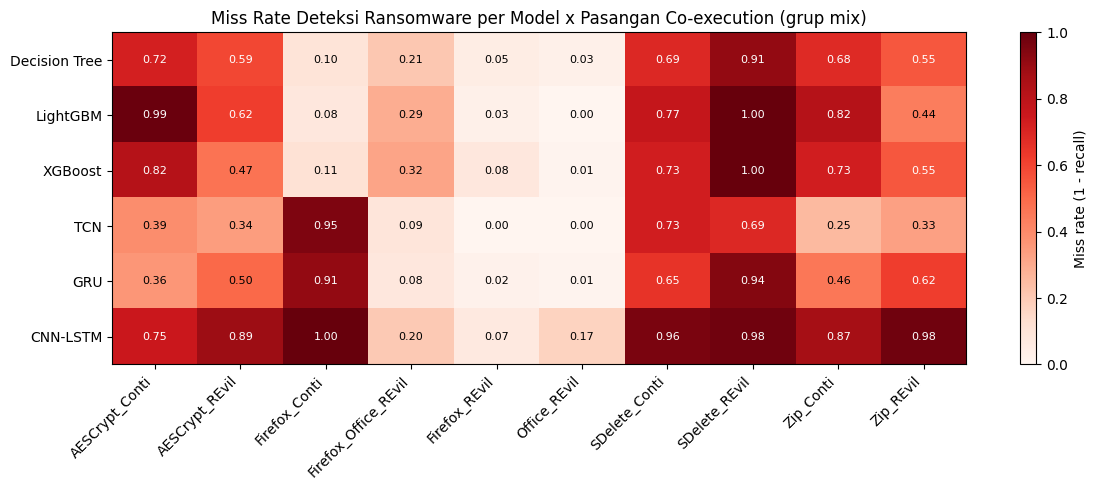

In [3]:
import matplotlib.pyplot as plt

mix_df = pd.read_csv(RESULTS_PATH)
mix_df["hit"] = mix_df["pred_label"]

summary = mix_df.groupby(["model", "pairing"])["hit"].agg(["mean", "count"]).rename(columns={"mean": "recall"})
summary["miss_rate"] = 1 - summary["recall"]
print("=== MISS RATE (1 - recall) PER MODEL x PASANGAN CO-EXECUTION ===")
print("(dari seluruh seed digabung -- tiap baris = rata-rata atas 5 pengulangan seed)")
print(summary.sort_values("miss_rate", ascending=False).to_string())

pivot = summary["miss_rate"].unstack("pairing").reindex(MODEL_NAMES)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if val > 0.5 else "black")
fig.colorbar(im, label="Miss rate (1 - recall)")
ax.set_title("Miss Rate Deteksi Ransomware per Model x Pasangan Co-execution (grup mix)")
plt.tight_layout()
plt.savefig("/kaggle/working/nb6b_miss_rate_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()